# Main V3 — All Fixes Applied

| Fix | Problem solved | Change |
|-----|----------------|--------|
| **FIX 1** | Only seizure-file interictal used → model trains on atypical interictal | Load **ALL** EDF files per patient; cap at 15 000 interictal windows |
| **FIX 2** | VAR(1) captures 4 ms — no EEG frequency information | VAR(**5**) via OLS, captures ~20 ms; GC = Σ\|Aᵢ\| |
| **FIX 3** | Every 10-second window is an independent alarm → FPR/h 90–270 | Sliding-window vote: K=8 of M=12 must be positive |
| **FIX 4** | Re-alarm possible immediately after alarm fires | 30-min refractory period after each alarm |

V2 improvements (focal loss, GC z-score normalisation, balanced sampler, LR decay) are all retained.

In [1]:
# --- portable repo bootstrap (added for public release; locates the repo root) ---
import sys as _sys, pathlib as _pl
REPO = _pl.Path.cwd()
while not (REPO / 'src' / 'config.py').exists() and REPO != REPO.parent:
    REPO = REPO.parent
_sys.path.insert(0, str(REPO / 'src'))
from pathlib import Path
CODE_DIR = str(REPO); CODE = REPO; CODEV2 = REPO; PROJECT_DIR = REPO
# --------------------------------------------------------------------------------

# ── Cell 0: Imports & config ──────────────────────────────────────────────────
# First run only — uncomment to install:
# !pip install mne torch scikit-learn numpy scipy pandas matplotlib --break-system-packages

import sys, os, copy, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Point this at the folder containing your updated .py files ────────────────
# [path set by bootstrap] CODE_DIR = r"<repo>/Code"
sys.path.insert(0, CODE_DIR)

from config import (
    DATA_ROOT, EXCLUDED_PATIENTS, CANONICAL_CHANNELS, N_CHANNELS,
    FS, RANDOM_SEED, RESULTS_DIR,
    GC_MATRICES_DIR_V3,
    INTERICTAL_MULTIPLIER,
    MAX_INTERICTAL_ABS,
    ALARM_K, ALARM_M, ALARM_REFRACTORY,
    GC_ORDER,
)
from summary_parser import (
    parse_all_summaries,
    parse_summary_with_times,
    get_clean_interictal_files,
)
from data_loader    import load_edf
from preprocessing  import bandpass_filter, segment_signal, label_windows
from granger        import process_file_to_gc, compute_gc_matrices
from metrics        import evaluate_predictions, evaluate_with_alarms

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── V3 hyperparameters ────────────────────────────────────────────────────────
V3_MAX_EPOCHS      = 50
V3_PATIENCE        = 10
V3_BATCH_SIZE      = 64
V3_LR              = 1e-3
V3_LR_DECAY        = 0.90
V3_FOCAL_GAMMA     = 2.0
V3_VAL_FRACTION    = 0.15
V3_MAX_WIN_PER_PAT = 1500

print(f'Device     : {DEVICE}')
print(f'GC order   : VAR({GC_ORDER})')
print(f'Cache dir  : {GC_MATRICES_DIR_V3}')
print(f'Interictal cap: {INTERICTAL_MULTIPLIER}× preictal  (hard ceil={MAX_INTERICTAL_ABS})')
print(f'Alarm K={ALARM_K}  M={ALARM_M}  Refractory={ALARM_REFRACTORY} windows ({ALARM_REFRACTORY*10//60} min)')
print('V3 config loaded.')


Device     : cpu
GC order   : VAR(5)
Cache dir  : /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/cache_gc_var5
Interictal cap: 5× preictal  (hard ceil=5000)
Alarm K=5  M=12  Refractory=180 windows (30 min)
V3 config loaded.


In [2]:
# ── Cell 1: Parse seizure summaries ──────────────────────────────────────────
all_seizures = parse_all_summaries(DATA_ROOT)
print(f'Parsed summaries for {len(all_seizures)} patients.')

[INFO] chb01: 7 seizure-containing files, 7 total seizures
[INFO] chb02: 3 seizure-containing files, 3 total seizures
[INFO] chb03: 7 seizure-containing files, 7 total seizures
[INFO] chb04: 3 seizure-containing files, 4 total seizures
[INFO] chb05: 5 seizure-containing files, 5 total seizures
[INFO] chb06: 7 seizure-containing files, 10 total seizures
[INFO] chb07: 3 seizure-containing files, 3 total seizures
[INFO] chb08: 5 seizure-containing files, 5 total seizures
[INFO] chb09: 3 seizure-containing files, 4 total seizures
[INFO] chb10: 7 seizure-containing files, 7 total seizures
[INFO] chb11: 3 seizure-containing files, 3 total seizures
[INFO] chb12: 13 seizure-containing files, 40 total seizures
[INFO] chb13: 8 seizure-containing files, 12 total seizures
[INFO] chb14: 7 seizure-containing files, 8 total seizures
[INFO] chb15: 14 seizure-containing files, 20 total seizures
[INFO] chb16: 6 seizure-containing files, 10 total seizures
[INFO] chb17: 3 seizure-containing files, 3 total

In [3]:
# ── Cell 2: Load ALL EDF files — with clean interictal filter (Option B) ─────
#
# For each patient:
#   1. parse_summary_with_times() → reconstructs absolute wall-clock timeline
#   2. get_clean_interictal_files() → keeps only files ≥ 4h from any seizure
#   3. Seizure files → preictal + interictal windows (as before)
#   4. Clean non-seizure files → interictal windows only
#   5. Interictal capped at INTERICTAL_MULTIPLIER × n_preictal  (1:5 ratio)
#
# This matches the standard literature criterion (Direito 2012, Ziyabari 2019):
# interictal must be ≥ 4h before seizure onset AND ≥ 4h after seizure offset.

CLEAN_GAP_HOURS = 4   # hours buffer on each side of any seizure

patient_data = {}
patients = sorted([
    p for p in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, p))
    and p.startswith('chb')
    and p not in EXCLUDED_PATIENTS
])

for patient_id in patients:
    file_seizure_map = all_seizures.get(patient_id, {})
    if not file_seizure_map:
        print(f'[SKIP] {patient_id}: no seizures in summary')
        continue

    patient_dir = os.path.join(DATA_ROOT, patient_id)

    # ── Step 1: Reconstruct absolute timeline ─────────────────────────────────
    try:
        timeline = parse_summary_with_times(patient_dir)
    except Exception as e:
        print(f'[SKIP] {patient_id}: timeline error — {e}')
        continue

    # ── Step 2: Identify clean interictal files ───────────────────────────────
    clean_files, excl_files = get_clean_interictal_files(
        timeline,
        pre_seizure_gap  = CLEAN_GAP_HOURS * 3600,
        post_seizure_gap = CLEAN_GAP_HOURS * 3600,
        verbose          = False,
    )
    clean_set = set(clean_files)

    print(f'\n{"─"*60}')
    print(f'Patient: {patient_id}  |  '
          f'{len(timeline)} total EDFs, '
          f'{len(file_seizure_map)} seizure files, '
          f'{len(clean_files)} clean interictal files '
          f'(excluded {len(excl_files)}, {CLEAN_GAP_HOURS}h buffer)')

    preictal_mats   = []
    interictal_mats = []

    all_edfs = sorted(Path(patient_dir).glob('*.edf'))

    for edf_path in all_edfs:
        fname           = edf_path.name
        is_seizure_file = fname in file_seizure_map
        is_clean_file   = fname in clean_set

        # Skip: not a seizure file and not a clean interictal file
        if not is_seizure_file and not is_clean_file:
            continue

        try:
            signal, fs = load_edf(str(edf_path))
        except Exception as e:
            print(f'  [SKIP] {fname}: {e}')
            continue

        filtered  = bandpass_filter(signal)
        n_samples = filtered.shape[1]

        if is_seizure_file:
            # ── Seizure file: full labelling ──────────────────────────────────
            windows_all = segment_signal(filtered)
            seizures    = file_seizure_map[fname]
            labels_all  = label_windows(n_samples, seizures)

            valid   = labels_all != -1
            windows = windows_all[valid]
            labels  = labels_all[valid]

            if (labels == 1).sum() == 0:
                # No usable preictal — treat whole file as interictal only
                mats, vmask = compute_gc_matrices(windows)
                interictal_mats.append(mats[vmask])
                print(f'  [szr,no-pre] {fname}  int={vmask.sum()}')
                continue

            mats, labels_gc = process_file_to_gc(
                windows, labels,
                patient_id=patient_id, fname=fname,
                use_cache=True, cache_dir=GC_MATRICES_DIR_V3,
                verbose=True,
            )
            pre_mask = labels_gc == 1
            int_mask = labels_gc == 0
            if pre_mask.sum() > 0:
                preictal_mats.append(mats[pre_mask])
            if int_mask.sum() > 0:
                interictal_mats.append(mats[int_mask])
            print(f'  [szr]  {fname}  pre={pre_mask.sum()}  int={int_mask.sum()}')

        else:
            # ── Clean interictal file: all windows labelled 0 ─────────────────
            windows_all = segment_signal(filtered)
            labels_all  = np.zeros(len(windows_all), dtype=np.int8)

            mats, labels_gc = process_file_to_gc(
                windows_all, labels_all,
                patient_id=patient_id, fname=fname,
                use_cache=True, cache_dir=GC_MATRICES_DIR_V3,
                verbose=False,
            )
            interictal_mats.append(mats)
            print(f'  [int]  {fname}  int={len(mats)}')

    # ── Combine preictal ──────────────────────────────────────────────────────
    if not preictal_mats:
        print(f'  [SKIP] {patient_id}: no preictal windows found')
        continue

    pre_X = np.concatenate(preictal_mats)
    pre_y = np.ones(len(pre_X), dtype=np.int8)

    # ── Combine + proportionally cap interictal ───────────────────────────────
    int_X_raw = np.concatenate(interictal_mats) if interictal_mats else np.empty((0, N_CHANNELS, N_CHANNELS))

    n_pre_this = len(pre_X)
    int_cap    = min(INTERICTAL_MULTIPLIER * n_pre_this, MAX_INTERICTAL_ABS)

    if len(int_X_raw) > int_cap:
        rng   = np.random.RandomState(RANDOM_SEED)
        idx   = rng.choice(len(int_X_raw), int_cap, replace=False)
        int_X = int_X_raw[idx]
    else:
        int_X = int_X_raw

    print(f'  Interictal: {len(int_X_raw)} available → capped to {len(int_X)} '
          f'({INTERICTAL_MULTIPLIER}×{n_pre_this} pre, ceil={MAX_INTERICTAL_ABS})')

    int_y = np.zeros(len(int_X), dtype=np.int8)

    # ── Concatenate + shuffle ─────────────────────────────────────────────────
    X   = np.concatenate([pre_X, int_X])
    y   = np.concatenate([pre_y, int_y])
    rng = np.random.RandomState(RANDOM_SEED)
    shf = rng.permutation(len(y))
    patient_data[patient_id] = (X[shf].astype(np.float32), y[shf].astype(np.int8))

    ratio = len(int_X) // max(n_pre_this, 1)
    print(f'  ✓ {patient_id}: total={len(y)}  '
          f'pre={n_pre_this}  int={len(int_X)}  ratio=1:{ratio}')

patient_ids = sorted(patient_data.keys())
print(f'\n{"="*62}')
print(f'Patients with data: {len(patient_ids)}')
print(patient_ids)



────────────────────────────────────────────────────────────
Patient: chb01  |  42 total EDFs, 7 seizure files, 13 clean interictal files (excluded 29, 4h buffer)
  [GC] Computing 294 VAR(5) matrices  chb01/chb01_03.edf ...
  [szr]  chb01_03.edf  pre=148  int=146
    [LABEL] Seizure at 1467s: preictal window out of bounds (would start at -333s) — skipping preictal label.
  [szr,no-pre] chb01_04.edf  int=174
  [int]  chb01_09.edf  int=359
  [int]  chb01_10.edf  int=359
    [LABEL] Seizure at 1732s: preictal window out of bounds (would start at -68s) — skipping preictal label.
  [szr,no-pre] chb01_15.edf  int=173
    [LABEL] Seizure at 1015s: preictal window out of bounds (would start at -785s) — skipping preictal label.
  [szr,no-pre] chb01_16.edf  int=172
    [LABEL] Seizure at 1720s: preictal window out of bounds (would start at -80s) — skipping preictal label.
  [szr,no-pre] chb01_18.edf  int=171
    [LABEL] Seizure at 327s: preictal window out of bounds (would start at -1473s) — sk

In [4]:
# ── Cell 3: Dataset summary ───────────────────────────────────────────────────
rows = []
for pid, (X, y) in patient_data.items():
    n_pre = int((y == 1).sum())
    n_int = int((y == 0).sum())
    rows.append({'patient': pid, 'n_preictal': n_pre, 'n_interictal': n_int,
                 'total': len(y), 'ratio': f'1:{n_int // max(n_pre,1)}'})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print(f'\nGrand total : {summary_df["total"].sum()} windows')
print(f'Total preictal   : {summary_df["n_preictal"].sum()}')
print(f'Total interictal : {summary_df["n_interictal"].sum()}')

patient  n_preictal  n_interictal  total ratio
  chb01         296          1480   1776   1:5
  chb02         296          1480   1776   1:5
  chb03         444          2220   2664   1:5
  chb04         296          1480   1776   1:5
  chb05         444          2220   2664   1:5
  chb06        1037          5000   6037   1:4
  chb07         445          2225   2670   1:5
  chb08         741           896   1637   1:1
  chb09         592          2960   3552   1:5
  chb10         888          4440   5328   1:5
  chb13         444          2220   2664   1:5
  chb14         774          2123   2897   1:2
  chb15         320          1600   1920   1:5
  chb16         347          1735   2082   1:5
  chb17         444          2220   2664   1:5
  chb18         592          2960   3552   1:5
  chb19         296          1480   1776   1:5
  chb20         369          1845   2214   1:5
  chb22         296          1480   1776   1:5
  chb23         608          3040   3648   1:5
  chb24      

In [5]:
# ── Cell 4: Model + loss + sampler (V2/V3 architecture) ──────────────────────

class GCDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N,1,18,18)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class GCPredictor(nn.Module):
    """2-D CNN: 3 conv blocks → 2 FC layers → sigmoid."""
    def __init__(self, n_channels=18, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1, 1, n_channels, n_channels)).numel()
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(flat, 256), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.classifier(self.features(x))


class BinaryFocalLoss(nn.Module):
    """FL = −α·(1−pₜ)^γ·log(pₜ)  with class-frequency α."""
    def __init__(self, gamma=2.0, pos_weight=1.0):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight
    def forward(self, preds, targets):
        p     = preds.squeeze(1).clamp(1e-7, 1-1e-7)
        t     = targets.float()
        alpha = torch.where(t==1, torch.full_like(t, self.pos_weight), torch.ones_like(t))
        bce   = -(t*torch.log(p) + (1-t)*torch.log(1-p))
        pt    = torch.where(t==1, p, 1-p)
        return (alpha * (1-pt)**self.gamma * bce).mean()


def make_balanced_sampler(patient_counts, max_per_patient):
    weights = []
    for n in patient_counts:
        w = min(max_per_patient, n) / n
        weights.extend([w] * n)
    weights   = torch.tensor(weights, dtype=torch.float32)
    n_samples = len(patient_counts) * max_per_patient
    return WeightedRandomSampler(weights, num_samples=n_samples, replacement=True)


print('Model components defined.')

Model components defined.


In [6]:
# ── Cell 5: Training & inference functions ────────────────────────────────────

def train_v3(X_tr, y_tr, X_va, y_va, patient_counts=None, verbose=True):
    set_seed()
    n_pos = max(int((y_tr==1).sum()), 1)
    n_neg = max(int((y_tr==0).sum()), 1)
    pos_w = float(min(n_neg/n_pos, 50.0))

    criterion = BinaryFocalLoss(gamma=V3_FOCAL_GAMMA, pos_weight=pos_w).to(DEVICE)
    model     = GCPredictor(N_CHANNELS).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=V3_LR)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma=V3_LR_DECAY)

    tr_ds = GCDataset(X_tr, y_tr)
    va_ds = GCDataset(X_va, y_va)

    if patient_counts is not None:
        sampler  = make_balanced_sampler(patient_counts, V3_MAX_WIN_PER_PAT)
        tr_dl    = DataLoader(tr_ds, batch_size=V3_BATCH_SIZE, sampler=sampler)
    else:
        tr_dl    = DataLoader(tr_ds, batch_size=V3_BATCH_SIZE, shuffle=True)

    va_dl = DataLoader(va_ds, batch_size=V3_BATCH_SIZE, shuffle=False)

    best_val, best_wts, p_ctr = float('inf'), None, 0

    for epoch in range(1, V3_MAX_EPOCHS+1):
        model.train()
        tr_loss = 0.0
        for xb, yb in tr_dl:
            xb, yb  = xb.to(DEVICE), yb.to(DEVICE)
            loss    = criterion(model(xb), yb)
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            tr_loss += loss.item() * len(yb)
        tr_loss /= len(tr_ds)

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb   = xb.to(DEVICE), yb.to(DEVICE)
                va_loss += criterion(model(xb), yb).item() * len(yb)
        va_loss /= len(va_ds)
        scheduler.step()

        if verbose and epoch % 5 == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f'    Epoch {epoch:3d}/{V3_MAX_EPOCHS}  '
                  f'train={tr_loss:.4f}  val={va_loss:.4f}  lr={lr_now:.6f}')

        if va_loss < best_val - 1e-6:
            best_val = va_loss
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            p_ctr    = 0
        else:
            p_ctr += 1
            if p_ctr >= V3_PATIENCE:
                if verbose: print(f'    Early stopping at epoch {epoch}.')
                break

    model.load_state_dict(best_wts)
    return model


def predict_proba(model, X):
    model.eval()
    dl  = DataLoader(GCDataset(X, np.zeros(len(X))), batch_size=V3_BATCH_SIZE)
    out = []
    with torch.no_grad():
        for xb, _ in dl:
            out.append(model(xb.to(DEVICE)).squeeze(1).cpu().numpy())
    return np.concatenate(out)


print('Training utilities ready.')

Training utilities ready.


In [7]:
from metrics import find_optimal_threshold

In [8]:
# ── Cell 6: LOPO V3 (all 4 fixes active) ─────────────────────────────────────

lopo_window_results = {}   # window-level  (AUC not affected by alarm logic)
lopo_alarm_results  = {}   # alarm-level   (FIX 3 + FIX 4 applied)

n_folds = len(patient_ids)
print('='*62)
print(f'LOPO V3  ({n_folds} folds)  |  device: {DEVICE}')
print(f'  FIX 1: all EDFs (1:{INTERICTAL_MULTIPLIER} cap)   FIX 2: VAR({GC_ORDER})\n'
      f'  FIX 3: K={ALARM_K}/M={ALARM_M}   FIX 4: refr={ALARM_REFRACTORY}w')
print('='*62)

for fold_idx, test_pid in enumerate(patient_ids, 1):
    print(f'\n[Fold {fold_idx}/{n_folds}]  Test: {test_pid}')

    train_pids = [p for p in patient_ids if p != test_pid]

    X_parts, y_parts, raw_counts = [], [], []
    for p in train_pids:
        Xp, yp = patient_data[p]
        X_parts.append(Xp); y_parts.append(yp); raw_counts.append(len(yp))

    X_pool = np.concatenate(X_parts)
    y_pool = np.concatenate(y_parts)

    # Stratified train/val split from TRAINING pool only
    tr_idx, va_idx = train_test_split(
        np.arange(len(y_pool)), test_size=V3_VAL_FRACTION,
        random_state=RANDOM_SEED, stratify=y_pool
    )
    X_tr, y_tr = X_pool[tr_idx], y_pool[tr_idx]
    X_va, y_va = X_pool[va_idx], y_pool[va_idx]
    X_te, y_te = patient_data[test_pid]

    # GC z-score normalisation — fit on TRAIN only (V2 improvement)
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr.reshape(len(X_tr), -1)).reshape(X_tr.shape)
    X_va   = scaler.transform(X_va.reshape(len(X_va), -1)).reshape(X_va.shape)
    X_te   = scaler.transform(X_te.reshape(len(X_te), -1)).reshape(X_te.shape)

    train_frac   = len(tr_idx) / len(y_pool)
    train_counts = [max(1, round(c * train_frac)) for c in raw_counts]

    print(f'  Train={len(y_tr)} (pre={(y_tr==1).sum()}, int={(y_tr==0).sum()})  '
          f'Val={len(y_va)}  Test={len(y_te)} (pre={(y_te==1).sum()})')

    model  = train_v3(X_tr, y_tr, X_va, y_va,
                      patient_counts=train_counts, verbose=True)
    probs     = predict_proba(model, X_te)
    probs_val = predict_proba(model, X_va)   # for threshold tuning

    # Per-fold optimal threshold via Youden index on VALIDATION set.
    # Using threshold=0.5 for all patients fails because the model
    # outputs probabilities clustered near 0 (high specificity bias).
    # The Youden index finds the threshold that maximises Sens+Spec-1
    # on the val set — this is computed BEFORE seeing the test set.
    opt_threshold = find_optimal_threshold(y_va, probs_val, criterion='youden')
    opt_threshold = float(np.clip(opt_threshold, 0.05, 0.95))  # safety bounds

    print(f'  Optimal threshold (val Youden): {opt_threshold:.3f}')

    # Window-level evaluation (AUC is threshold-independent — keep it)
    w_met = evaluate_predictions(
        y_te, probs, threshold=opt_threshold, patient_id=test_pid
    )

    # Alarm-level evaluation (FIX 3 + FIX 4) using optimal threshold
    a_met = evaluate_with_alarms(
        y_te, probs, threshold=opt_threshold,
        K=ALARM_K, M=ALARM_M, refractory_windows=ALARM_REFRACTORY,
        patient_id=test_pid
    )

    lopo_window_results[test_pid] = w_met
    lopo_alarm_results[test_pid]  = a_met

    print(f'  -> [window] AUC={w_met["auc"]:.3f}  '
          f'Sens={w_met["sensitivity"]:.3f}  '
          f'Spec={w_met["specificity"]:.3f}  '
          f'FPR/h={w_met["fpr_per_hour"]:.1f}  '
          f'thr={opt_threshold:.3f}')
    print(f'     [alarm]  AUC={a_met["auc"]:.3f}  '
          f'Sens={a_met["sensitivity"]:.3f}  '
          f'Spec={a_met["specificity"]:.3f}  '
          f'FPR/h={a_met["fpr_per_hour"]:.1f}')

print(f'\n{"="*62}')
print('LOPO V3 complete.')


LOPO V3  (21 folds)  |  device: cpu
  FIX 1: all EDFs (1:5 cap)   FIX 2: VAR(5)
  FIX 3: K=5/M=12   FIX 4: refr=180w

[Fold 1/21]  Test: chb01
  Train=47532 (pre=9020, int=38512)  Val=8388  Test=1776 (pre=296)
    Epoch   5/50  train=0.0867  val=0.1503  lr=0.000590
    Epoch  10/50  train=0.0581  val=0.1273  lr=0.000349
    Epoch  15/50  train=0.0428  val=0.1278  lr=0.000206
    Epoch  20/50  train=0.0352  val=0.1255  lr=0.000122
    Epoch  25/50  train=0.0306  val=0.1460  lr=0.000072
    Early stopping at epoch 27.
  Optimal threshold (val Youden): 0.453
  -> [window] AUC=0.550  Sens=0.139  Spec=0.893  FPR/h=38.7  thr=0.453
     [alarm]  AUC=0.550  Sens=0.000  Spec=0.999  FPR/h=0.2

[Fold 2/21]  Test: chb02
  Train=47532 (pre=9020, int=38512)  Val=8388  Test=1776 (pre=296)
    Epoch   5/50  train=0.0879  val=0.1390  lr=0.000590
    Epoch  10/50  train=0.0598  val=0.1210  lr=0.000349
    Epoch  15/50  train=0.0452  val=0.1232  lr=0.000206
    Epoch  20/50  train=0.0369  val=0.1263  lr=

In [9]:
# ── Cell 7: Save results ──────────────────────────────────────────────────────
os.makedirs(RESULTS_DIR, exist_ok=True)

METRIC_KEYS = ['auc', 'auc_pr', 'sensitivity', 'specificity',
               'f1', 'balanced_accuracy', 'fpr_per_hour']

def to_df(results_dict, pid_list):
    rows = [{'patient': pid, **{k: results_dict[pid][k] for k in METRIC_KEYS}}
            for pid in pid_list if pid in results_dict]
    df = pd.DataFrame(rows)
    df = pd.concat([
        df,
        pd.DataFrame([{'patient': 'MEAN', **{k: round(df[k].mean(), 4) for k in METRIC_KEYS}}]),
        pd.DataFrame([{'patient': 'STD',  **{k: round(df[k].std(),  4) for k in METRIC_KEYS}}]),
    ], ignore_index=True)
    return df

win_df   = to_df(lopo_window_results, patient_ids)
alarm_df = to_df(lopo_alarm_results,  patient_ids)

win_df.to_csv(os.path.join(RESULTS_DIR,   'lopo_v3_window.csv'), index=False)
alarm_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_v3_alarm.csv'),  index=False)

# lopo_results.csv = the canonical GC-CNN result that comparison notebooks read.
# V3 alarm-level is our best result, so we write it as the new canonical file.
alarm_df.to_csv(os.path.join(RESULTS_DIR, 'lopo_results.csv'), index=False)
print('  Also saved as lopo_results.csv (read by all comparison notebooks)')

print('='*62)
print('LOPO V3 — Window-Level (AUC is key metric here)')
print('='*62)
print(win_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\n' + '='*62)
print(f'LOPO V3 — Alarm-Level  (K={ALARM_K}/M={ALARM_M}, Refractory={ALARM_REFRACTORY}w)')
print('='*62)
print(alarm_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f'\nResults saved to {RESULTS_DIR}/')


  Also saved as lopo_results.csv (read by all comparison notebooks)
LOPO V3 — Window-Level (AUC is key metric here)
patient    auc  auc_pr  sensitivity  specificity     f1  balanced_accuracy  fpr_per_hour
  chb01 0.5502  0.1974       0.1385       0.8926 0.1653             0.5155       38.6757
  chb02 0.5270  0.2398       0.1689       0.9365 0.2273             0.5527       22.8649
  chb03 0.3461  0.1204       0.0203       0.9464 0.0315             0.4833       19.2973
  chb04 0.4025  0.1376       0.1419       0.8149 0.1373             0.4784       66.6486
  chb05 0.4222  0.1389       0.1532       0.7063 0.1168             0.4297      105.7297
  chb06 0.4616  0.1560       0.2257       0.7296 0.1784             0.4776       97.3440
  chb07 0.7089  0.2912       0.1775       0.9276 0.2307             0.5526       26.0494
  chb08 0.5913  0.5225       0.8138       0.2935 0.6100             0.5536      254.3304
  chb09 0.5554  0.1892       0.1166       0.9051 0.1465             0.5108       34

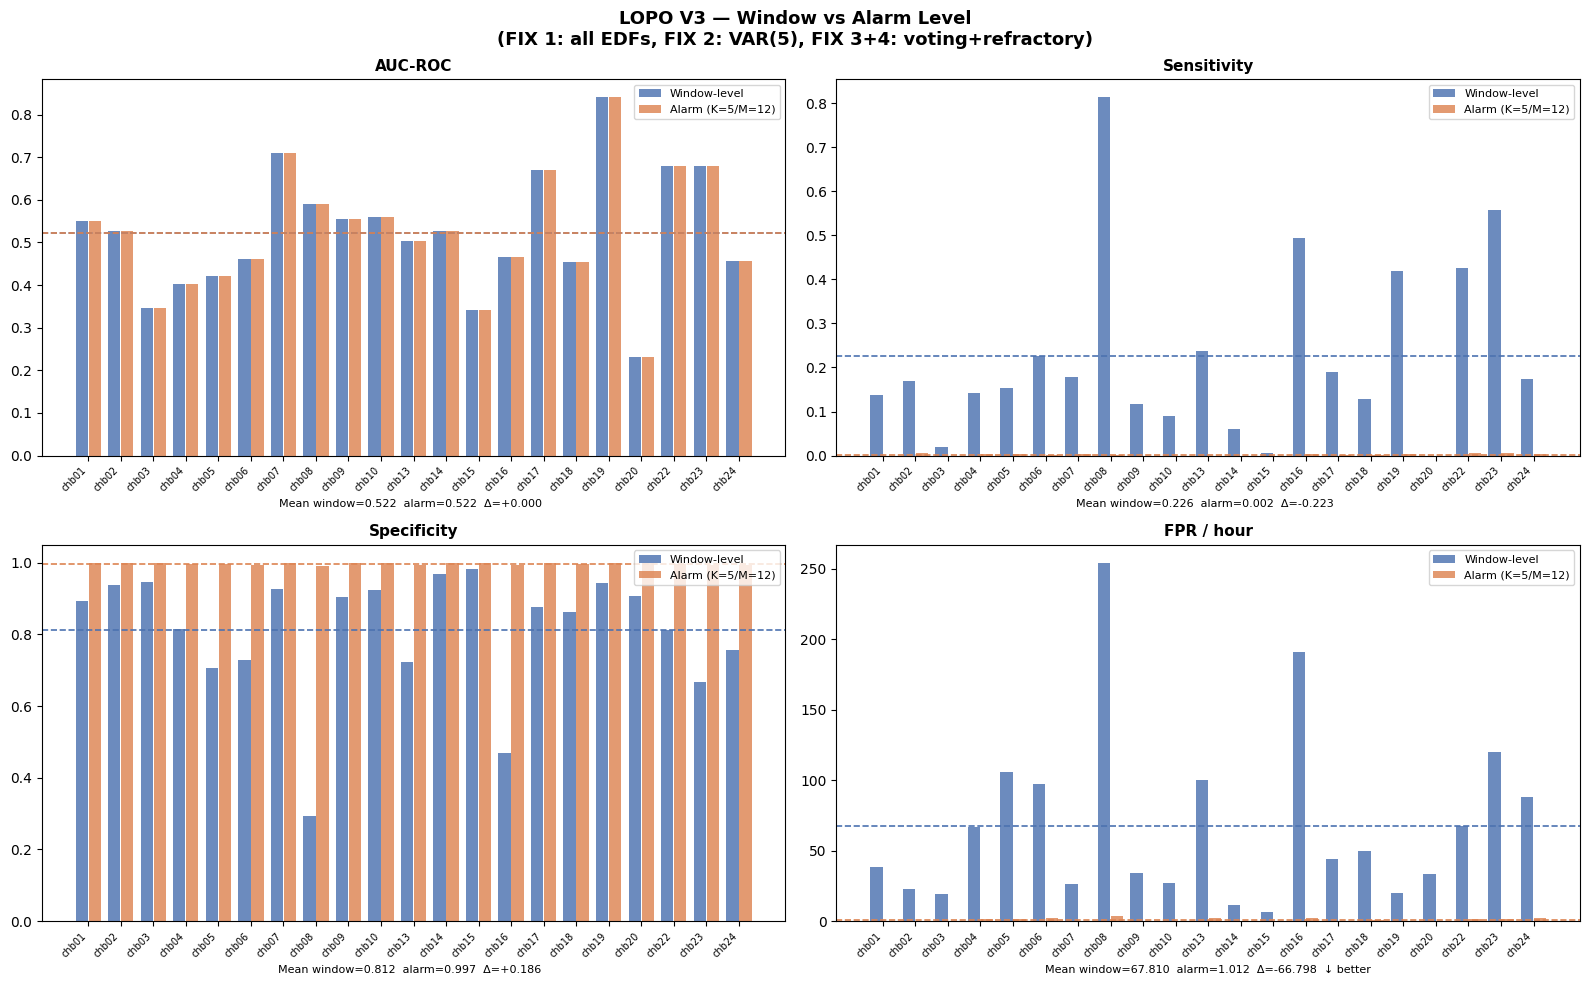

Saved: /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/v3_window_vs_alarm.png


In [10]:
# ── Cell 8: Main comparison plot (window vs alarm metrics) ────────────────────

win_plot   = win_df[~win_df['patient'].isin(['MEAN','STD'])].copy()
alarm_plot = alarm_df[~alarm_df['patient'].isin(['MEAN','STD'])].copy()
pids_plot  = win_plot['patient'].tolist()
x          = np.arange(len(pids_plot))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_cfg = [
    ('auc',         'AUC-ROC',       False),  # (col, title, higher=better inverted)
    ('sensitivity', 'Sensitivity',   False),
    ('specificity', 'Specificity',   False),
    ('fpr_per_hour','FPR / hour',    True),   # lower is better
]

for ax, (metric, title, invert) in zip(axes.flat, metrics_cfg):
    w_vals = win_plot[metric].values.astype(float)
    a_vals = alarm_plot[metric].values.astype(float)
    mw     = np.nanmean(w_vals)
    ma     = np.nanmean(a_vals)
    delta  = ma - mw
    sign   = '+' if delta >= 0 else ''

    ax.bar(x - 0.2, w_vals, 0.38, label='Window-level', color='#4C72B0', alpha=0.82)
    ax.bar(x + 0.2, a_vals, 0.38, label=f'Alarm (K={ALARM_K}/M={ALARM_M})', color='#DD8452', alpha=0.82)
    ax.axhline(mw, color='#4C72B0', linestyle='--', lw=1.2)
    ax.axhline(ma, color='#DD8452', linestyle='--', lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(pids_plot, rotation=45, ha='right', fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    direction = '↓ better' if invert else ''
    ax.set_xlabel(f'Mean window={mw:.3f}  alarm={ma:.3f}  Δ={sign}{delta:.3f}  {direction}',
                  fontsize=8)

plt.suptitle('LOPO V3 — Window vs Alarm Level\n'
             f'(FIX 1: all EDFs, FIX 2: VAR({GC_ORDER}), FIX 3+4: voting+refractory)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = os.path.join(RESULTS_DIR, 'v3_window_vs_alarm.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

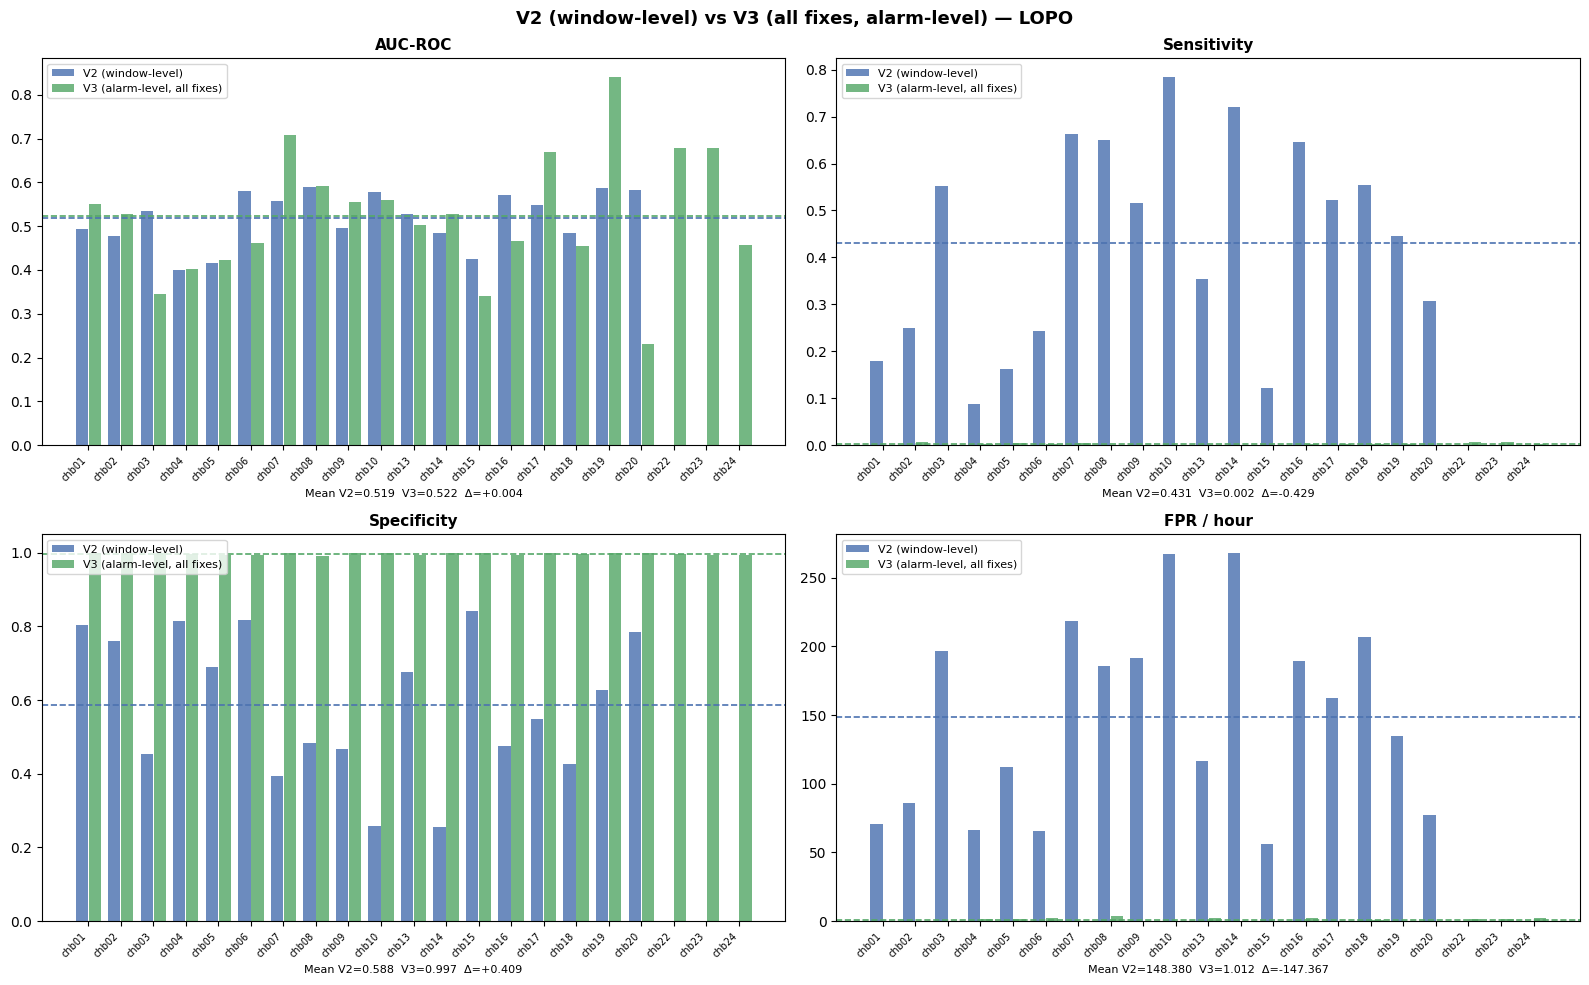

Saved: /Users/goncalopacheco/Documents/Master's/2º Year/Thesis/Code Final/results/v2_vs_v3_lopo.png


In [11]:
# ── Cell 9: Compare V2 LOPO vs V3 LOPO ───────────────────────────────────────
# Only runs if you have lopo_v2_results.csv from Main_V2.ipynb

v2_csv = os.path.join(RESULTS_DIR, 'lopo_v2_results.csv')

if not os.path.exists(v2_csv):
    print(f'V2 results not found at {v2_csv}  —  run Main_V2.ipynb first to get comparison.')
else:
    v2_df    = pd.read_csv(v2_csv)
    pid_col  = [c for c in v2_df.columns if 'patient' in c.lower()][0]
    v2_df    = v2_df.rename(columns={pid_col: 'patient'})
    v2_df    = v2_df[~v2_df['patient'].astype(str).isin(['MEAN','STD'])].copy()
    v3_alarm = alarm_df[~alarm_df['patient'].isin(['MEAN','STD'])].copy()

    compare = ['auc', 'sensitivity', 'specificity', 'fpr_per_hour']
    titles  = ['AUC-ROC', 'Sensitivity', 'Specificity', 'FPR / hour']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for ax, metric, title in zip(axes.flat, compare, titles):
        pids = v3_alarm['patient'].tolist()
        x    = np.arange(len(pids))

        v2_vals, v3_vals = [], []
        for p in pids:
            r2 = v2_df[v2_df['patient'] == p]
            v2_vals.append(float(r2[metric].values[0]) if len(r2) and metric in v2_df.columns else np.nan)
            r3 = v3_alarm[v3_alarm['patient'] == p]
            v3_vals.append(float(r3[metric].values[0]) if len(r3) else np.nan)

        m2 = np.nanmean(v2_vals)
        m3 = np.nanmean(v3_vals)
        d  = m3 - m2
        sign = '+' if d >= 0 else ''

        ax.bar(x-0.2, v2_vals, 0.38, label='V2 (window-level)',
               color='#4C72B0', alpha=0.82)
        ax.bar(x+0.2, v3_vals, 0.38,
               label=f'V3 (alarm-level, all fixes)',
               color='#55A868', alpha=0.82)
        ax.axhline(m2, color='#4C72B0', linestyle='--', lw=1.2)
        ax.axhline(m3, color='#55A868', linestyle='--', lw=1.2)
        ax.set_xticks(x)
        ax.set_xticklabels(pids, rotation=45, ha='right', fontsize=7)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlabel(f'Mean V2={m2:.3f}  V3={m3:.3f}  Δ={sign}{d:.3f}', fontsize=8)

    plt.suptitle('V2 (window-level) vs V3 (all fixes, alarm-level) — LOPO',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(RESULTS_DIR, 'v2_vs_v3_lopo.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

In [12]:
# ── Cell 10: Final text summary ───────────────────────────────────────────────

print('\n' + '='*62)
print('V3 FINAL SUMMARY')
print('='*62)

for label, df in [('Window-level', win_df), ('Alarm-level', alarm_df)]:
    mean_row = df[df['patient'] == 'MEAN'].iloc[0]
    std_row  = df[df['patient'] == 'STD'].iloc[0]
    print(f'\n  {label}:')
    for k in METRIC_KEYS:
        print(f'    {k:20s}: {mean_row[k]:.4f} ± {std_row[k]:.4f}')

print('\n  Alarm parameters:')
print(f'    K={ALARM_K} of M={ALARM_M} windows  |  '
      f'Refractory={ALARM_REFRACTORY} windows ({ALARM_REFRACTORY*10//60} min)')
print('='*62)


V3 FINAL SUMMARY

  Window-level:
    auc                 : 0.5224 ± 0.1421
    auc_pr              : 0.2297 ± 0.1165
    sensitivity         : 0.2255 ± 0.2053
    specificity         : 0.8116 ± 0.1727
    f1                  : 0.2032 ± 0.1487
    balanced_accuracy   : 0.5186 ± 0.0604
    fpr_per_hour        : 67.8105 ± 62.1829

  Alarm-level:
    auc                 : 0.5224 ± 0.1421
    auc_pr              : 0.2297 ± 0.1165
    sensitivity         : 0.0023 ± 0.0024
    specificity         : 0.9972 ± 0.0030
    f1                  : 0.0046 ± 0.0047
    balanced_accuracy   : 0.4998 ± 0.0017
    fpr_per_hour        : 1.0125 ± 1.0649

  Alarm parameters:
    K=5 of M=12 windows  |  Refractory=180 windows (30 min)
